# What kinds of racing make up British horse racing?

British horse racing is organised around two main forms of racing: **Flat racing** and **Jump racing**.

That distinction matters because the individual race types we see in the Inside Rails data are not four equivalent top-level categories.

The broad structure is:

- **Flat racing**
  - Flat races

- **Jump racing (National Hunt)**
  - Hurdle races
  - Steeple Chases / Chases
  - National Hunt Flat races

National Hunt Flat races are a potentially confusing case. They are run without obstacles, but they belong to the Jump programme and are commonly used to give prospective Jump horses racecourse experience before progressing to hurdles or fences.

For this study, that means the broad analytical distinction will ultimately be:

- **Flat:** Flat
- **Jump:** Hurdle + Chase + National Hunt Flat

We will not assume this structure merely because those labels appear in the database. We first establish the terminology from British racing sources, then examine whether the governed Inside Rails race-type classification represents it appropriately.

## First question

**Does the Inside Rails study classification correspond to these recognised forms of British racing?**

In [1]:
from pathlib import Path

import pandas as pd

from inside_rails.source_sqlite import connect_read_only
from inside_rails.study_overlay import build_race_overlay_query


# Use the accepted immutable Database v3 analytical release.
#
# This notebook is under:
# studies/jurisdictions/great_britain/
#
# so the database is three directory levels above the notebook location.
DB_PATH = Path(
    "../../../data/processed/database/releases/inside_rails_v3.sqlite3"
)


# Select the Great Britain race population from the preferred race-level view.
#
# The overlay helper requires these base fields to be exposed:
# - raw_date
# - raw_course
# - raw_off
# - race_type_raw
# - advertised_start_course_local
#
# raw_off is included only because the governed post-v3 overlay uses exact
# source date + course + off identity to match verified corrections.
# It is not being analysed or displayed in this study.
base_query = """
SELECT
    raw_date,
    raw_course,
    raw_off,
    race_type_raw,
    advertised_start_course_local,
    candidate_jurisdiction
FROM view_reconciled_race_occurrences
WHERE candidate_jurisdiction = 'Great Britain'
"""


# Wrap the Database v3 race query with the governed read-only post-v3 overlay.
#
# race_type_study retains the Database v3 value unless an exact race has a
# verified post-v3 correction. The accepted database itself remains unchanged.
overlay_sql, overlay_params = build_race_overlay_query(base_query)


# Count the study-facing race classifications and retain their provenance.
#
# Grouping by race_type_study_source lets us see both:
# - the broad categories represented in the study population;
# - how many race classifications are supplied by Database v3 versus the
#   governed post-v3 correction overlay.
#
# This is only a structural check. We are not yet calculating the reader-facing
# Flat-versus-Jump split or interpreting the relative prevalence of race types.
with connect_read_only(DB_PATH) as conn:
    race_types = pd.read_sql_query(
        f"""
        SELECT
            race_type_study,
            race_type_study_source,
            COUNT(*) AS races
        FROM ({overlay_sql})
        GROUP BY
            race_type_study,
            race_type_study_source
        ORDER BY races DESC
        """,
        conn,
        params=overlay_params,
    )


# Display the complete result for inspection before deciding the next step.
race_types

,race_type_study,race_type_study_source,races
0,Flat,database_v3,70205
1,Hurdle,database_v3,22644
2,Chase,database_v3,15660
3,NH Flat,database_v3,3100
4,Hurdle,post_v3_external_overlay,9
5,NH Flat,post_v3_external_overlay,9
6,Chase,post_v3_external_overlay,4
7,Flat,post_v3_external_overlay,3


In [2]:
# Collapse Database v3 values and governed post-v3 corrections into the final
# study-facing race type. Each race is counted once under race_type_study.

with connect_read_only(DB_PATH) as conn:
    race_type_totals = pd.read_sql_query(
        f"""
        SELECT
            race_type_study,
            COUNT(*) AS races
        FROM ({overlay_sql})
        GROUP BY race_type_study
        ORDER BY races DESC
        """,
        conn,
        params=overlay_params,
    )

# Add each race type's share of the full Great Britain study population.
race_type_totals["percentage"] = (
    race_type_totals["races"] / race_type_totals["races"].sum() * 100
).round(1)

race_type_totals

,race_type_study,races,percentage
0,Flat,70208,62.9
1,Hurdle,22653,20.3
2,Chase,15664,14.0
3,NH Flat,3109,2.8


### Flat racing makes up most of the British programme

Across the 111,634 Great Britain races in the study period, the governed race-type classification gives:

| Race type | Races | Share |
|---|---:|---:|
| Flat | 70,208 | 62.9% |
| Hurdle | 22,653 | 20.3% |
| Chase | 15,664 | 14.0% |
| National Hunt Flat | 3,109 | 2.8% |

Flat racing is the largest individual part of the programme, accounting for almost two-thirds of all races.

Among the individual Jump forms, Hurdle racing is the most common, followed by Chases. National Hunt Flat races form a much smaller part of the overall programme.

These four categories describe individual race forms. Because Hurdle, Chase and National Hunt Flat racing all sit within the broader Jump side of British racing, the next question is whether the overall programme is best understood as roughly two-thirds Flat and one-third Jump.

In [3]:
# Collapse the four study-facing race types into the two top-level forms
# established from the British racing terminology above.

flat_jump_totals = (
    race_type_totals.assign(
        racing_form=race_type_totals["race_type_study"].map(
            {
                "Flat": "Flat",
                "Hurdle": "Jump",
                "Chase": "Jump",
                "NH Flat": "Jump",
            }
        )
    )
    .groupby("racing_form", as_index=False)["races"]
    .sum()
    .sort_values("races", ascending=False)
    .reset_index(drop=True)
)

# Calculate each top-level form's share of the full Great Britain population.
flat_jump_totals["percentage"] = (
    flat_jump_totals["races"] / flat_jump_totals["races"].sum() * 100
).round(1)

flat_jump_totals

,racing_form,races,percentage
0,Flat,70208,62.9
1,Jump,41426,37.1


### British racing is roughly three-fifths Flat and two-fifths Jump

Once Hurdle, Chase and National Hunt Flat races are combined into the broader Jump category, the 111,634-race study population divides into:

| Form | Races | Share |
|---|---:|---:|
| Flat | 70,208 | 62.9% |
| Jump | 41,426 | 37.1% |

Flat racing therefore accounts for almost two-thirds of the British programme across the study period, while just over one-third is Jump racing.

This top-level split is more informative than treating Flat, Hurdle, Chase and National Hunt Flat as four equivalent forms, because it reflects the recognised structure of British racing.

The next question is how the Jump programme itself is divided between Hurdles, Chases and National Hunt Flat races.

In [4]:
# Restrict the governed study-facing race types to the three forms that make up
# the Jump programme.

jump_composition = race_type_totals.loc[
    race_type_totals["race_type_study"].isin(["Hurdle", "Chase", "NH Flat"]),
    ["race_type_study", "races"],
].copy()

# Calculate each Jump form's share of the 41,426 Jump races rather than its
# share of the full British racing programme.

jump_composition["percentage_of_jump"] = (
    jump_composition["races"] / jump_composition["races"].sum() * 100
).round(1)

jump_composition = (
    jump_composition.sort_values("races", ascending=False)
    .reset_index(drop=True)
)

jump_composition

,race_type_study,races,percentage_of_jump
0,Hurdle,22653,54.7
1,Chase,15664,37.8
2,NH Flat,3109,7.5


### Most Jump racing is over hurdles

Within the 41,426 Jump races in the study population:

| Jump race type | Races | Share of Jump racing |
|---|---:|---:|
| Hurdle | 22,653 | 54.7% |
| Chase | 15,664 | 37.8% |
| National Hunt Flat | 3,109 | 7.5% |

Hurdle racing makes up just over half of the Jump programme.

Chases account for a little under two-fifths, while National Hunt Flat races form a much smaller part of the Jump programme.

So the broad structure of British racing across the study period is not simply Flat versus Jump. Within the Jump side, Hurdles are the dominant race form, Chases are substantial but less common, and National Hunt Flat races are relatively rare.

In [5]:
# Derive calendar month from the race date and map the governed race types to
# the two top-level forms established earlier.

with connect_read_only(DB_PATH) as conn:
    monthly_flat_jump = pd.read_sql_query(
        f"""
        SELECT
            CAST(substr(raw_date, 6, 2) AS INTEGER) AS month,
            CASE
                WHEN race_type_study = 'Flat' THEN 'Flat'
                WHEN race_type_study IN ('Hurdle', 'Chase', 'NH Flat') THEN 'Jump'
            END AS racing_form,
            COUNT(*) AS races
        FROM ({overlay_sql})
        GROUP BY
            month,
            racing_form
        ORDER BY
            month,
            racing_form
        """,
        conn,
        params=overlay_params,
    )

# Calculate the total number of races staged in each calendar month across the
# full study period.

monthly_flat_jump["month_total"] = (
    monthly_flat_jump.groupby("month")["races"].transform("sum")
)

# Express Flat and Jump racing as a share of all races staged in that month.

monthly_flat_jump["percentage_of_month"] = (
    monthly_flat_jump["races"] / monthly_flat_jump["month_total"] * 100
).round(1)

monthly_flat_jump

,month,racing_form,races,month_total,percentage_of_month
0,1,Flat,4015,7943,50.5
1,1,Jump,3928,7943,49.5
2,2,Flat,3221,7478,43.1
3,2,Jump,4257,7478,56.9
4,3,Flat,3374,8491,39.7
5,3,Jump,5117,8491,60.3
6,4,Flat,5662,9681,58.5
7,4,Jump,4019,9681,41.5
8,5,Flat,7783,11519,67.6
9,5,Jump,3736,11519,32.4


In [6]:
# Restrict the seasonal comparison to complete calendar years while excluding
# 2020, which Study 01 established as structurally exceptional.

with connect_read_only(DB_PATH) as conn:
    monthly_flat_jump_by_year = pd.read_sql_query(
        f"""
        SELECT
            CAST(substr(raw_date, 1, 4) AS INTEGER) AS year,
            CAST(substr(raw_date, 6, 2) AS INTEGER) AS month,
            CASE
                WHEN race_type_study = 'Flat' THEN 'Flat'
                WHEN race_type_study IN ('Hurdle', 'Chase', 'NH Flat') THEN 'Jump'
            END AS racing_form,
            COUNT(*) AS races
        FROM ({overlay_sql})
        WHERE CAST(substr(raw_date, 1, 4) AS INTEGER)
              IN (2015, 2016, 2017, 2018, 2019,
                  2021, 2022, 2023, 2024, 2025)
        GROUP BY
            year,
            month,
            racing_form
        ORDER BY
            year,
            month,
            racing_form
        """,
        conn,
        params=overlay_params,
    )

# Calculate Flat and Jump shares separately within every calendar month of
# every included year.

monthly_flat_jump_by_year["month_total"] = (
    monthly_flat_jump_by_year
    .groupby(["year", "month"])["races"]
    .transform("sum")
)

monthly_flat_jump_by_year["percentage_of_month"] = (
    monthly_flat_jump_by_year["races"]
    / monthly_flat_jump_by_year["month_total"]
    * 100
)

# Give each complete non-2020 year equal weight when summarising the typical
# Flat/Jump balance for each calendar month.

monthly_flat_jump_typical = (
    monthly_flat_jump_by_year
    .groupby(["month", "racing_form"], as_index=False)
    .agg(
        mean_percentage=("percentage_of_month", "mean"),
        minimum_percentage=("percentage_of_month", "min"),
        maximum_percentage=("percentage_of_month", "max"),
        years=("year", "nunique"),
    )
)

monthly_flat_jump_typical[
    ["mean_percentage", "minimum_percentage", "maximum_percentage"]
] = monthly_flat_jump_typical[
    ["mean_percentage", "minimum_percentage", "maximum_percentage"]
].round(1)

monthly_flat_jump_typical

,month,racing_form,mean_percentage,minimum_percentage,maximum_percentage,years
0,1,Flat,50.5,42.4,58.8,10
1,1,Jump,49.5,41.2,57.6,10
2,2,Flat,42.1,38.2,46.3,10
3,2,Jump,57.9,53.7,61.8,10
4,3,Flat,39.3,35.3,46.5,10
5,3,Jump,60.7,53.5,64.7,10
6,4,Flat,58.1,52.4,63.5,10
7,4,Jump,41.9,36.5,47.6,10
8,5,Flat,67.4,64.5,71.2,10
9,5,Jump,32.6,28.8,35.5,10


### Flat and Jump racing dominate at different times of year

The balance between Flat and Jump racing changes sharply through the calendar year.

Using the ten complete non-2020 years from 2015–2019 and 2021–2025:

- Jump racing is the majority form in February, March, November and December.
- January is almost evenly divided between Flat and Jump racing.
- Flat racing becomes dominant from April onwards and reaches its strongest position in summer.
- August is the clearest extreme: on average, 87.7% of races are Flat and only 12.3% are Jump.
- The pattern then reverses through autumn, with Jump racing returning to a majority share by November.

The year-to-year ranges show that this is not driven by one unusual season. In every included year, Flat racing remained strongly dominant through the summer months, while Jump racing consistently accounted for a much larger share of the programme in late autumn and winter.

British racing therefore has a pronounced seasonal structure not only in the overall number of races staged, but also in the kinds of racing that make up the programme.

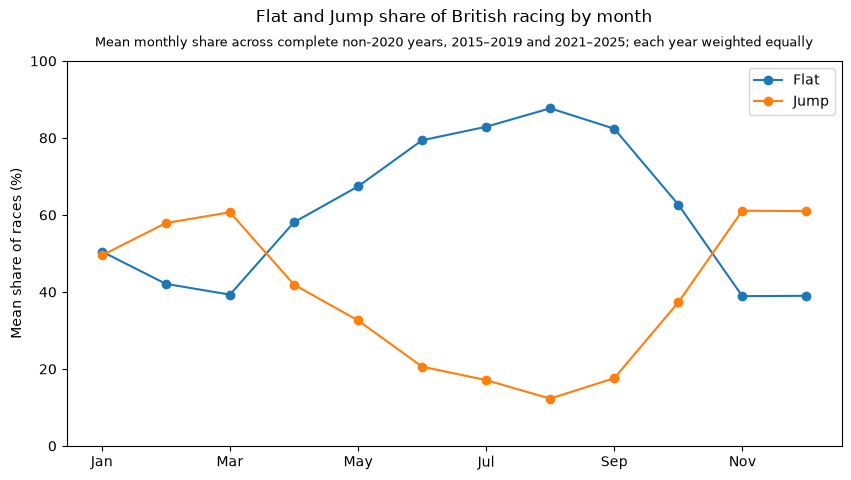

In [7]:
# Reshape the typical monthly Flat/Jump shares so each racing form becomes a
# separate line in the reader-facing chart.

monthly_share_plot = (
    monthly_flat_jump_typical
    .pivot(
        index="month",
        columns="racing_form",
        values="mean_percentage",
    )
    .reset_index()
)

# Replace numeric months with abbreviated calendar labels.

month_labels = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}

monthly_share_plot["month_label"] = (
    monthly_share_plot["month"].map(month_labels)
)

# Plot the mean monthly Flat and Jump shares across the ten complete non-2020
# years. Percentage shares show programme composition rather than race volume.

ax = monthly_share_plot.plot(
    x="month_label",
    y=["Flat", "Jump"],
    kind="line",
    marker="o",
    figsize=(10, 5),
)

ax.set_title(
    "Flat and Jump share of British racing by month",
    pad=28,
)

# Keep the population and period qualification attached to the figure itself.

ax.text(
    0.5,
    1.03,
    (
        "Mean monthly share across complete non-2020 years, "
        "2015–2019 and 2021–2025; each year weighted equally"
    ),
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9,
)

ax.set_xlabel("")
ax.set_ylabel("Mean share of races (%)")
ax.set_ylim(0, 100)
ax.legend(title="");


In [8]:
# Test whether Flat and Jump races are normally staged on separate course-date
# programmes or combined within the same analytical meeting.
#
# Study 01 defined a course-date meeting as races sharing raw_date and
# candidate_course_label. That definition is reused here only for this
# established analytical purpose; it is not a definition of a physical venue
# or an official BHA fixture.

meeting_base_query = """
SELECT
    raw_date,
    raw_course,
    raw_off,
    race_type_raw,
    advertised_start_course_local,
    candidate_course_label,
    candidate_jurisdiction
FROM view_reconciled_race_occurrences
WHERE candidate_jurisdiction = 'Great Britain'
"""

meeting_overlay_sql, meeting_overlay_params = build_race_overlay_query(
    meeting_base_query
)

# For each course-date meeting, record whether at least one Flat race and at
# least one Jump race were present after applying the governed corrections.

with connect_read_only(DB_PATH) as conn:
    meeting_composition = pd.read_sql_query(
        f"""
        WITH meeting_flags AS (
            SELECT
                raw_date,
                candidate_course_label,
                MAX(
                    CASE
                        WHEN race_type_study = 'Flat' THEN 1
                        ELSE 0
                    END
                ) AS has_flat,
                MAX(
                    CASE
                        WHEN race_type_study IN ('Hurdle', 'Chase', 'NH Flat')
                        THEN 1
                        ELSE 0
                    END
                ) AS has_jump
            FROM ({meeting_overlay_sql})
            GROUP BY
                raw_date,
                candidate_course_label
        )
        SELECT
            CASE
                WHEN has_flat = 1 AND has_jump = 0 THEN 'Flat only'
                WHEN has_flat = 0 AND has_jump = 1 THEN 'Jump only'
                WHEN has_flat = 1 AND has_jump = 1 THEN 'Mixed Flat + Jump'
            END AS meeting_type,
            COUNT(*) AS meetings
        FROM meeting_flags
        GROUP BY
            has_flat,
            has_jump
        ORDER BY meetings DESC
        """,
        conn,
        params=meeting_overlay_params,
    )

# Show each meeting type as a share of all observed course-date meetings.

meeting_composition["percentage"] = (
    meeting_composition["meetings"]
    / meeting_composition["meetings"].sum()
    * 100
).round(2)

meeting_composition

,meeting_type,meetings,percentage
0,Flat only,9786,61.68
1,Jump only,6068,38.25
2,Mixed Flat + Jump,11,0.07


### Flat and Jump racing are almost always kept separate within meetings

Across the 15,865 Great Britain course-date meetings observed in the study period:

| Meeting type | Meetings | Share |
|---|---:|---:|
| Flat only | 9,786 | 61.68% |
| Jump only | 6,068 | 38.25% |
| Mixed Flat + Jump | 11 | 0.07% |

Flat and Jump races were therefore almost always staged in separate course-date programmes.

Only 11 of the 15,865 observed meetings contained both Flat and Jump races, representing just 0.07% of the total.

This reinforces the practical importance of the Flat/Jump distinction. It is not only a conceptual classification of individual races: in the observed British programme, it also corresponds almost completely to how races are grouped into meetings.

In [9]:
# Measure the monthly composition of the Jump programme across complete
# non-2020 years only.

with connect_read_only(DB_PATH) as conn:
    monthly_jump_by_year = pd.read_sql_query(
        f"""
        SELECT
            CAST(substr(raw_date, 1, 4) AS INTEGER) AS year,
            CAST(substr(raw_date, 6, 2) AS INTEGER) AS month,
            race_type_study,
            COUNT(*) AS races
        FROM ({overlay_sql})
        WHERE
            race_type_study IN ('Hurdle', 'Chase', 'NH Flat')
            AND CAST(substr(raw_date, 1, 4) AS INTEGER)
                IN (2015, 2016, 2017, 2018, 2019,
                    2021, 2022, 2023, 2024, 2025)
        GROUP BY
            year,
            month,
            race_type_study
        ORDER BY
            year,
            month,
            race_type_study
        """,
        conn,
        params=overlay_params,
    )

# Calculate each Jump race type's share within the Jump programme for each
# month of each included year.

monthly_jump_by_year["jump_month_total"] = (
    monthly_jump_by_year
    .groupby(["year", "month"])["races"]
    .transform("sum")
)

monthly_jump_by_year["percentage_of_jump_month"] = (
    monthly_jump_by_year["races"]
    / monthly_jump_by_year["jump_month_total"]
    * 100
)

# Give each complete non-2020 year equal weight when summarising the typical
# monthly composition of Jump racing.

monthly_jump_typical = (
    monthly_jump_by_year
    .groupby(["month", "race_type_study"], as_index=False)
    .agg(
        mean_percentage=("percentage_of_jump_month", "mean"),
        minimum_percentage=("percentage_of_jump_month", "min"),
        maximum_percentage=("percentage_of_jump_month", "max"),
        years=("year", "nunique"),
    )
)

monthly_jump_typical[
    ["mean_percentage", "minimum_percentage", "maximum_percentage"]
] = monthly_jump_typical[
    ["mean_percentage", "minimum_percentage", "maximum_percentage"]
].round(1)

monthly_jump_typical

,month,race_type_study,mean_percentage,minimum_percentage,maximum_percentage,years
0,1,Chase,37.2,31.7,38.9,10
1,1,Hurdle,55.1,49.4,57.4,10
2,1,NH Flat,7.7,5.2,18.9,10
3,2,Chase,39.3,35.9,40.9,10
4,2,Hurdle,51.4,42.1,54.4,10
5,2,NH Flat,9.3,6.8,22.0,10
6,3,Chase,37.8,36.5,39.1,10
7,3,Hurdle,53.9,50.4,56.0,10
8,3,NH Flat,8.3,6.6,12.7,10
9,4,Chase,39.7,35.0,43.1,10


### The mix within Jump racing changes less dramatically through the year

The seasonal shift within Jump racing is much smaller than the overall seasonal shift between Flat and Jump racing.

Across the ten complete non-2020 years:

- Hurdle racing is the largest component of the Jump programme in every calendar month.
- Its mean monthly share ranges from 51.4% in February to 60.1% in August.
- Chases consistently form the second-largest component, ranging from 34.5% to 39.7%.
- National Hunt Flat races remain a relatively small part of the Jump programme throughout the year, generally accounting for around 5–9%.

The clearest movement occurs in summer, when Hurdles make up a somewhat larger share of the remaining Jump programme and Chases a somewhat smaller share.

This should be read alongside the much stronger Flat/Jump seasonal pattern above. Jump racing itself is much less common in summer, so these percentages describe the composition of a smaller summer Jump programme rather than an increase in the absolute amount of Hurdle racing.

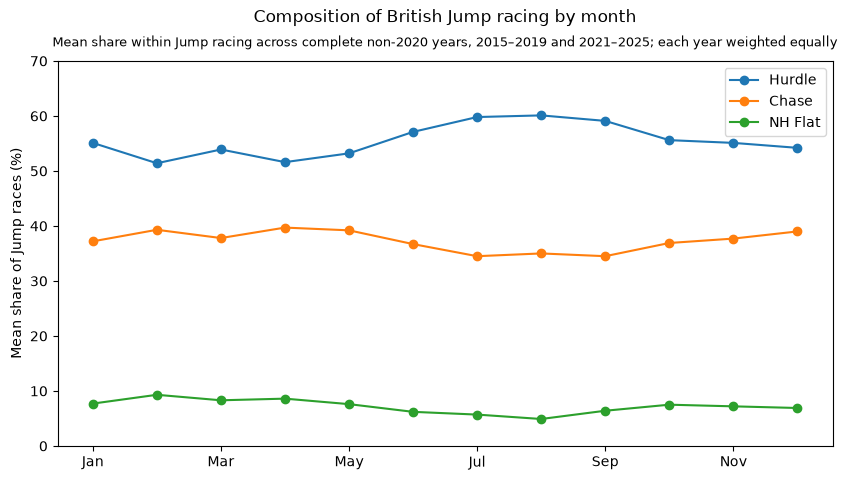

In [10]:
# Reshape the typical monthly Jump composition so Hurdle, Chase and NH Flat
# become separate series in the reader-facing chart.

monthly_jump_plot = (
    monthly_jump_typical
    .pivot(
        index="month",
        columns="race_type_study",
        values="mean_percentage",
    )
    .reset_index()
)

# Use the same calendar-month labels as the Flat/Jump seasonal chart.

monthly_jump_plot["month_label"] = (
    monthly_jump_plot["month"].map(month_labels)
)

# Plot the mean composition of the Jump programme across the ten complete
# non-2020 years. These are shares within Jump racing, not shares of all racing.

ax = monthly_jump_plot.plot(
    x="month_label",
    y=["Hurdle", "Chase", "NH Flat"],
    kind="line",
    marker="o",
    figsize=(10, 5),
)

ax.set_title(
    "Composition of British Jump racing by month",
    pad=28,
)

# Keep the denominator and period qualification attached to the figure.

ax.text(
    0.5,
    1.03,
    (
        "Mean share within Jump racing across complete non-2020 years, "
        "2015–2019 and 2021–2025; each year weighted equally"
    ),
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9,
)

ax.set_xlabel("")
ax.set_ylabel("Mean share of Jump races (%)")
ax.set_ylim(0, 70)
ax.legend(title="");

## What kinds of racing make up British horse racing?

British horse racing is best understood as two broad forms: **Flat racing** and **Jump racing**.

The study classification separates races into four operational categories — Flat, Hurdle, Chase and National Hunt Flat — but these are not four equivalent top-level forms. Hurdle, Chase and National Hunt Flat races together make up the Jump programme.

Across the 111,634 Great Britain races observed from 1 January 2015 to 27 May 2026:

- **70,208 races (62.9%) were Flat**
- **41,426 races (37.1%) were Jump**

Within Jump racing:

- **22,653 races (54.7%) were Hurdles**
- **15,664 races (37.8%) were Chases**
- **3,109 races (7.5%) were National Hunt Flat races**

The distinction is also visible in how British racing is organised.

Across 15,865 observed course-date meetings, 9,786 were Flat-only and 6,068 were Jump-only. Just **11 meetings — 0.07% — contained both Flat and Jump races**. In practice, the two forms were therefore almost completely separated at meeting level during the study period.

There is also a strong seasonal divide.

Across the ten complete non-2020 years studied, Jump racing formed the majority of the programme in February, March, November and December, while January was almost evenly divided. Flat racing became dominant from April and accounted for more than four-fifths of racing in July, August and September on average.

August showed the strongest Flat dominance, with an average **87.7% Flat / 12.3% Jump** split.

The composition within Jump racing was much more stable. Hurdles were the largest Jump category in every month, Chases remained the second largest, and National Hunt Flat races were consistently a small minority.

### In short

British racing is not one homogeneous programme split into several interchangeable race labels.

It has a clear structural divide between **Flat and Jump racing**, those forms dominate at different times of year, and they are almost always staged in separate meetings. Within the Jump programme, **Hurdle racing is the most common form, followed by Chases, with National Hunt Flat racing making up a much smaller component**.

This study does not attempt to define racecourses, classes, handicap structures or the many more detailed race conditions within these forms. Those are separate questions.

## Limitations and provenance

This study describes Great Britain races recorded in the accepted historical database from **1 January 2015 to 27 May 2026**. It is therefore a description of the observed programme over that period, not a claim about all British racing historically or about races staged after the database cut-off.

Race type is analysed using the governed `race_type_study` classification. This retains the Database v3 value except where an exact race has a verified post-v3 correction. The underlying source field is structurally complete and generally reliable for broad descriptive analysis, but targeted investigation has shown that it is not error-free. The study therefore uses the governed corrections rather than treating the raw source classification as infallible.

The seasonal comparisons use the ten complete non-2020 years **2015–2019 and 2021–2025**. The exceptional 2020 programme is excluded from those comparisons, and partial 2026 is not treated as a complete year. Each included year receives equal weight when mean monthly percentages are calculated.

Meeting-level results use the study's analytical course-date meeting definition: races sharing `raw_date` and `candidate_course_label`. This is useful for measuring how races were grouped in the observed data, but it should not be treated as a definitive statement about official fixture, racecourse or physical-venue identity.

The study establishes the broad relationship between Flat racing and the Jump programme, including Hurdle, Chase and National Hunt Flat racing. It does not attempt to explain race class, handicapping, eligibility conditions, racecourse identity, surface, going, distance or detailed race subtypes. Those require separate bounded studies.

In [11]:
# Persist the principal study tables outside the immutable database.
#
# These outputs are limited to the tables that directly support the study's
# conclusions. Exploratory intermediate tables are not persisted.

from pathlib import Path

OUTPUT_DIR = (
    Path("../../../data/processed/studies/")
    / "great_britain"
    / "02_types_of_british_racing"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Four-category governed race-type totals.

race_type_totals.to_csv(
    OUTPUT_DIR / "race_type_totals.csv",
    index=False,
)

# Top-level Flat versus Jump totals.

flat_jump_totals.to_csv(
    OUTPUT_DIR / "flat_jump_totals.csv",
    index=False,
)

# Composition of the Jump programme.

jump_composition.to_csv(
    OUTPUT_DIR / "jump_composition.csv",
    index=False,
)

# Course-date meeting composition.

meeting_composition.to_csv(
    OUTPUT_DIR / "meeting_composition.csv",
    index=False,
)

# Typical monthly Flat/Jump composition across complete non-2020 years.

monthly_flat_jump_typical.to_csv(
    OUTPUT_DIR / "monthly_flat_jump_typical.csv",
    index=False,
)

# Typical monthly Hurdle/Chase/NH Flat composition within Jump racing.

monthly_jump_typical.to_csv(
    OUTPUT_DIR / "monthly_jump_typical.csv",
    index=False,
)

print("Persisted study outputs to:")
print(OUTPUT_DIR)

for output_path in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  {output_path.name}")

Persisted study outputs to:
../../../data/processed/studies/great_britain/02_types_of_british_racing
  flat_jump_totals.csv
  jump_composition.csv
  meeting_composition.csv
  monthly_flat_jump_typical.csv
  monthly_jump_typical.csv
  race_type_totals.csv


In [12]:
# Persist a compact provenance manifest alongside the study outputs so the
# saved CSVs remain interpretable without reopening the notebook.

import json

provenance = {
    "study": "What kinds of racing make up British horse racing?",
    "notebook": "studies/jurisdictions/great_britain/02_types_of_british_racing.ipynb",
    "database": str(DB_PATH),
    "jurisdiction": "Great Britain",
    "study_period": {
        "start": "2015-01-01",
        "end": "2026-05-27",
    },
    "race_type_classification": {
        "field": "race_type_study",
        "method": (
            "Database v3 classification with verified post-v3 corrections "
            "applied through the study overlay"
        ),
    },
    "top_level_mapping": {
        "Flat": ["Flat"],
        "Jump": ["Hurdle", "Chase", "NH Flat"],
    },
    "meeting_definition": {
        "fields": ["raw_date", "candidate_course_label"],
        "description": (
            "Analytical course-date meeting definition; not treated as an "
            "official fixture or physical-venue identity"
        ),
    },
    "seasonal_comparison": {
        "included_years": [
            2015, 2016, 2017, 2018, 2019,
            2021, 2022, 2023, 2024, 2025,
        ],
        "excluded_years": {
            "2020": "structurally exceptional programme",
            "2026": "partial year",
        },
        "weighting": "Each included year weighted equally",
    },
    "outputs": [
        "race_type_totals.csv",
        "flat_jump_totals.csv",
        "jump_composition.csv",
        "meeting_composition.csv",
        "monthly_flat_jump_typical.csv",
        "monthly_jump_typical.csv",
    ],
}

provenance_path = OUTPUT_DIR / "provenance.json"

with provenance_path.open("w", encoding="utf-8") as f:
    json.dump(provenance, f, indent=2)

print(f"Persisted provenance manifest to:\n{provenance_path}")

Persisted provenance manifest to:
../../../data/processed/studies/great_britain/02_types_of_british_racing/provenance.json


In [13]:
# Re-read the persisted outputs from disk and verify that the headline totals
# still reproduce the conclusions recorded in the notebook.

persisted_race_types = pd.read_csv(
    OUTPUT_DIR / "race_type_totals.csv"
)

persisted_flat_jump = pd.read_csv(
    OUTPUT_DIR / "flat_jump_totals.csv"
)

persisted_meetings = pd.read_csv(
    OUTPUT_DIR / "meeting_composition.csv"
)

# Headline race population.

assert persisted_race_types["races"].sum() == 111_634

# Top-level Flat / Jump totals.

flat_total = int(
    persisted_flat_jump.loc[
        persisted_flat_jump["racing_form"] == "Flat",
        "races",
    ].iloc[0]
)

jump_total = int(
    persisted_flat_jump.loc[
        persisted_flat_jump["racing_form"] == "Jump",
        "races",
    ].iloc[0]
)

assert flat_total == 70_208
assert jump_total == 41_426
assert flat_total + jump_total == 111_634

# Course-date meeting totals and the corrected mixed-meeting result.

assert persisted_meetings["meetings"].sum() == 15_865

mixed_meetings = int(
    persisted_meetings.loc[
        persisted_meetings["meeting_type"] == "Mixed Flat + Jump",
        "meetings",
    ].iloc[0]
)

assert mixed_meetings == 11

print("Persisted outputs reproduce the headline study results.")
print(f"Races: {flat_total + jump_total:,}")
print(f"Flat: {flat_total:,}")
print(f"Jump: {jump_total:,}")
print(f"Course-date meetings: {persisted_meetings['meetings'].sum():,}")
print(f"Mixed Flat + Jump meetings: {mixed_meetings}")

Persisted outputs reproduce the headline study results.
Races: 111,634
Flat: 70,208
Jump: 41,426
Course-date meetings: 15,865
Mixed Flat + Jump meetings: 11


# Create the formal Study 02 closeout document from the results established in
# this notebook so far.
#
# Reproducibility and final closeout status are deliberately left pending
# because those checks have not yet been performed.

CLOSEOUT_PATH = (
    Path("../../../docs/studies/")
    / "GB_02_TYPES_OF_BRITISH_RACING_CLOSEOUT.md"
)

closeout_text = """# Great Britain Study 02 — Types of British Racing Closeout

## Study

Notebook:

`studies/jurisdictions/great_britain/02_types_of_british_racing.ipynb`

Supporting field-governance investigation:

`notebooks/race_type_raw_semantics.ipynb`

Accepted analytical database:

`data/processed/database/releases/inside_rails_v3.sqlite3`

Database status: accepted, immutable, read-only.

Study population: 111,634 Great Britain races from 1 January 2015 through 27 May 2026.

## Bounded question

**What kinds of racing make up British horse racing?**

The study describes the broad structure of British racing at the level of Flat and Jump racing, then examines the composition of the Jump programme, meeting-level separation and seasonal variation.

It does not extend into racecourse identity, race class, handicapping, eligibility conditions, going, distance or detailed race subtypes.

## Classification used

British racing is treated as two broad forms:

- **Flat racing**
- **Jump racing**

The governed study field `race_type_study` contains four operational categories:

- `Flat`
- `Hurdle`
- `Chase`
- `NH Flat`

These are not treated as four equivalent top-level forms.

For this study:

- `Flat` maps to **Flat racing**;
- `Hurdle`, `Chase` and `NH Flat` map to **Jump racing**.

National Hunt Flat racing therefore belongs to the Jump programme despite being run without obstacles.

The study uses the governed `race_type_study` value supplied by `inside_rails.study_overlay`. Database v3 remains immutable; verified post-v3 corrections are applied only through the study-facing overlay.

## Principal findings

Across 111,634 Great Britain races:

- 70,208 were Flat races — **62.9%**;
- 41,426 were Jump races — **37.1%**.

Within the 41,426 Jump races:

- 22,653 were Hurdles — **54.7%**;
- 15,664 were Chases — **37.8%**;
- 3,109 were National Hunt Flat races — **7.5%**.

Flat racing therefore accounted for almost two-thirds of the observed British programme, while Hurdles were the most common individual form within Jump racing.

## Meeting composition

For meeting-level analysis, the study reuses the Study 01 analytical definition of a **course-date meeting**: races sharing `raw_date` and `candidate_course_label`.

Across 15,865 observed course-date meetings:

- 9,786 were Flat-only — **61.68%**;
- 6,068 were Jump-only — **38.25%**;
- 11 contained both Flat and Jump races — **0.07%**.

Flat and Jump racing were therefore almost completely separated at course-date meeting level in the observed programme.

This analytical grouping is not presented as an official BHA fixture definition or as a definitive physical-racecourse identity.

## Seasonal structure

The normal seasonal comparison uses the ten complete non-2020 years:

- 2015–2019;
- 2021–2025.

2020 is excluded because Study 01 established it as structurally exceptional, and 2026 is excluded because the database ends on 27 May.

Each included year receives equal weight when mean monthly percentages are calculated.

The Flat/Jump balance changes sharply through the year:

- January is approximately evenly divided;
- Jump racing forms the majority in February and March;
- Flat racing becomes the majority from April;
- Flat racing accounts for more than four-fifths of racing on average in July, August and September;
- August is the strongest Flat month by composition, averaging **87.7% Flat and 12.3% Jump**;
- Jump racing returns to a majority share in November and December.

The pattern is stable across the ten normal complete years rather than being driven by a single season.

## Seasonal composition within Jump racing

The composition of Jump racing changes much less dramatically than the overall Flat/Jump balance.

Across the ten complete non-2020 years:

- Hurdles are the largest component of Jump racing in every calendar month;
- their mean monthly share ranges from 51.4% to 60.1%;
- Chases remain the second-largest component, ranging from 34.5% to 39.7%;
- National Hunt Flat races remain a small minority, generally around 5–9%.

The principal seasonal change in British racing is therefore the changing balance between Flat and Jump racing, rather than a major reordering of the forms within the Jump programme.

## Supporting race-type governance

The raw source field `race_type_raw` was investigated separately rather than silently corrected within this study.

That investigation established that:

- all 111,634 Great Britain races have one of the four broad stored values `Flat`, `Hurdle`, `Chase` or `NH Flat`;
- 25 exact source classifications were externally verified as wrong;
- those known corrections are applied through the governed post-v3 study overlay;
- an independent stratified pilot of 200 additional races, 50 from each stored category, agreed with external evidence in all 200 cases.

The field is therefore suitable for broad descriptive analysis with the governed corrections applied, but it is not claimed to be error-free.

## Persisted outputs

Principal study results have been persisted to:

`data/processed/studies/great_britain/02_types_of_british_racing/`

The persisted files are:

- `race_type_totals.csv`
- `flat_jump_totals.csv`
- `jump_composition.csv`
- `meeting_composition.csv`
- `monthly_flat_jump_typical.csv`
- `monthly_jump_typical.csv`
- `provenance.json`

The provenance manifest records the database, study population, classification mapping, meeting definition, seasonal comparison years and weighting used by the study.

A notebook-side persistence check successfully re-read the saved outputs and reproduced:

- 111,634 total races;
- 70,208 Flat races;
- 41,426 Jump races;
- 15,865 course-date meetings;
- 11 mixed Flat/Jump meetings.

## Reusable implementation decision

**No new reusable analytical implementation is currently required.**

The correctness-critical reusable behaviour required by this study is application of governed post-v3 race-type corrections. That is already provided by `inside_rails.study_overlay`.

The Flat/Jump mapping used here is a transparent study classification rather than a new database entity or source transformation.

## Database and integration consequence

**No Database v3 migration is authorised by this study.**

- Database v3 remains unchanged and read-only.
- governed race-type corrections remain in the post-v3 study overlay;
- the course-date meeting definition remains study-specific;
- `candidate_course_label` is not promoted to a definition of a physical racecourse;
- course identity and physical-venue semantics remain deferred to a later bounded study.

## Confidence and limitations

Confidence is high for the broad descriptive findings within the declared Great Britain population.

Important limits are:

- the study covers 1 January 2015 through 27 May 2026 rather than all British racing historically;
- 2026 is partial;
- 2020 is excluded from normal seasonal comparisons because it is structurally exceptional;
- `race_type_study` is governed and corrected where exact errors are known, but is not claimed to represent independent external verification of every race;
- the course-date meeting is an analytical grouping rather than an official fixture or physical-venue definition;
- the study describes programme structure, not scheduling causes, commercial importance or betting value;
- race class, handicapping, course identity, surface, going, distance and detailed race conditions remain outside scope.

## Reader-facing conclusion

British racing is best understood as two broad programmes: **Flat and Jump racing**.

Across the observed 111,634-race population, Flat racing accounted for 62.9% of races and Jump racing for 37.1%. Within Jump racing, Hurdles were the largest component, followed by Chases, with National Hunt Flat races making up a much smaller share.

The distinction is visible not only in race classification but in the structure of the programme. Just 11 of 15,865 observed course-date meetings contained both Flat and Jump races.

The two forms also dominate at different times of year. Flat racing is overwhelmingly dominant in summer, while Jump racing forms a much larger share of the late-autumn and winter programme.

The evidence therefore supports treating Flat and Jump racing as a genuine structural divide in the observed British racing programme rather than as interchangeable labels applied to otherwise similar races.

## Reproducibility

**Pending fresh-kernel execution.**

The notebook must still be executed from top to bottom in a fresh kernel against accepted Database v3 using the documented repository environment.

## Unit-test decision

**Pending final closeout review.**

No new parser, canonical source transformation or reusable classifier has been introduced by the study itself.

## Independent-validator decision

**Pending final closeout review.**

The study does not currently create a new source-wide transformation or governed reference requiring an additional production admission gate.

## Revisit-register decision

**Pending final closeout review.**

## Lessons learned

**Pending final closeout review.**

## Closeout status

**In progress — 10 August 2026.**

Analytical work: complete.

Persisted outputs: complete and headline totals re-read successfully.

Fresh-kernel reproducibility: pending.

Manual/external evidence review: pending final closeout check.

Reusable implementation decision: provisionally not applicable beyond existing study overlay.

Database migration: not applicable.

Reader-facing conclusion: recorded above.

Final repository closeout updates: pending.
"""

# Ensure the closeout directory exists, then write the current closeout draft.

CLOSEOUT_PATH.parent.mkdir(parents=True, exist_ok=True)
CLOSEOUT_PATH.write_text(closeout_text, encoding="utf-8")

print(f"Created Study 02 closeout draft:\n{CLOSEOUT_PATH}")